In [183]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [184]:
# Load csv as df
path="../../data/simon-data/properties-2b-located.csv"
properties=pd.read_csv(path,index_col=0)
pd.set_option('display.max_columns',None)

# Correct types and index
properties[['Number of rooms','Fully equipped kitchen','Number of facades','State of the building']]=properties[['Number of rooms','Fully equipped kitchen','Number of facades','State of the building']].astype(int)
properties=properties.drop('index',axis=1)
properties['Zip code']=properties['Zip code'].astype(str)


<Axes: xlabel='Region', ylabel='count'>

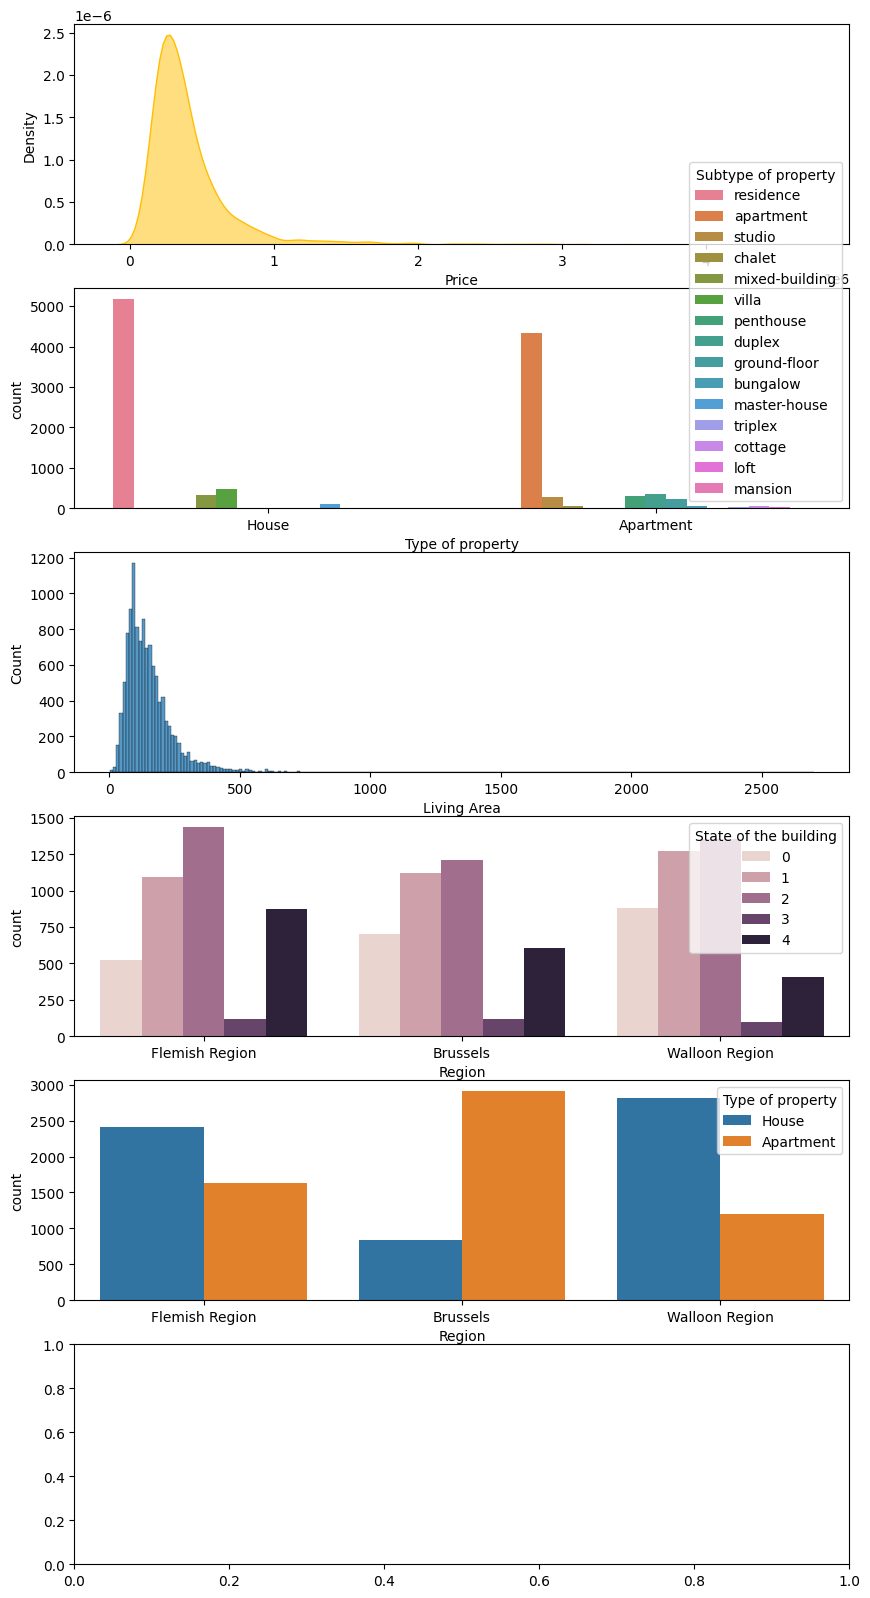

In [202]:
# Visualization
## Distributions - Prices (kde) - Type and subtype (hist) - Type of sale (pie) - Living Area (kde) - State of building (hist)
fig, axes = plt.subplots(6, 1, figsize=(10, 20))
sns.kdeplot(properties['Price'],ax=axes[0],fill=True,color='#FFBF00',alpha=0.5)
sns.countplot(data=properties,x="Type of property",hue="Subtype of property",ax=axes[1])
sns.histplot(properties['Living Area'],ax=axes[2])
sns.countplot(data=properties,x='Region',hue='State of the building',ax=axes[3])
sns.countplot(data=properties,x='Region',hue='Type of property',ax=axes[4])


Text(0.5, 1.0, 'Correlation with Price')

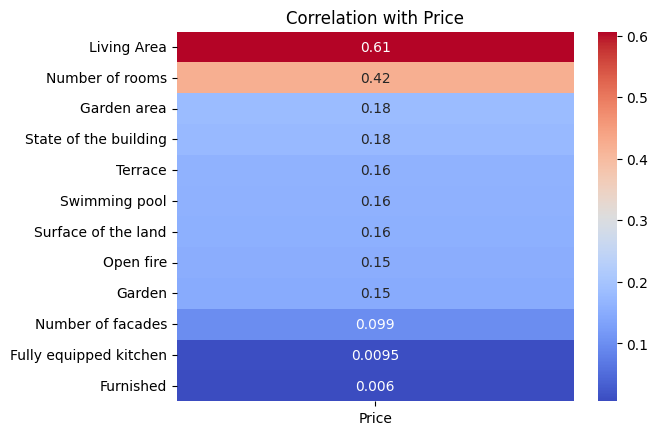

In [186]:
# Correlation with Price
corr_data=properties.select_dtypes('number').corr()[['Price']].sort_values(by='Price',ascending=False)

# Remove Price from columns
corr_data=corr_data.drop('Price')

# Plot
sns.heatmap(corr_data, annot=True, cmap="coolwarm")
plt.title("Correlation with Price")


Text(0.5, 1.0, 'Price distribution among Regions')

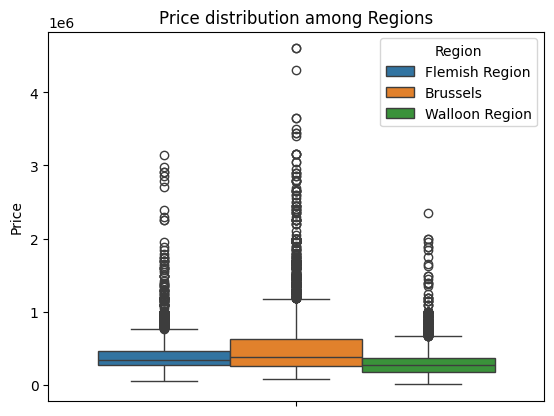

In [187]:
sns.boxplot(data=properties,hue='Region',y='Price')
plt.title('Price distribution among Regions')

Region
Brussels          530939.334045
Flemish Region    402146.166831
Walloon Region    306680.656865
Name: Price, dtype: float64 Region
Brussels          390000.0
Flemish Region    349000.0
Walloon Region    269000.0
Name: Price, dtype: float64 Province
Antwerp            378217.621524
Brussels           530939.334045
East Flanders      387499.560099
Flemish Brabant    496523.358885
Hainaut            235053.232893
Limburg            367211.695707
Liège              269527.800478
Luxembourg         292463.656552
Namur              271331.946292
Walloon Brabant    460643.099282
West Flanders      373411.601307
Name: Price, dtype: float64 Province
Antwerp            329500.0
Brussels           390000.0
East Flanders      360000.0
Flemish Brabant    426891.0
Hainaut            199000.0
Limburg            329000.0
Liège              242968.0
Luxembourg         260000.0
Namur              250000.0
Walloon Brabant    395000.0
West Flanders      325000.0
Name: Price, dtype: float64


<Axes: xlabel='Price', ylabel='count'>

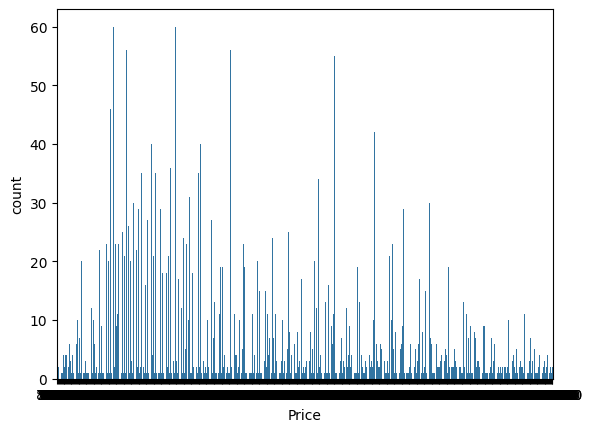

In [203]:
#Per Province & Region
# Median and mean price per Region
region_median_price=properties.groupby('Region')['Price'].median()
region_mean_price=properties.groupby('Region')['Price'].mean()

# Median and mean price per Province
province_median_price=properties.groupby('Province')['Price'].median()
province_mean_price=properties.groupby('Province')['Price'].mean()

print(region_mean_price,region_median_price,province_mean_price,province_median_price)

## Subsets
brussels_prop=properties[properties['Region']=='Brussels']
wallonia_prop=properties[properties['Region']=='Walloon Region']
flanders_prop=properties[properties['Region']=='Flemish Region']

sns.countplot(data=brussels_prop,x='Price')

In [189]:
## Geospatial distribution of prices
region_median_price=properties.groupby('Region')['Price'].median()
province_median_price=properties.groupby('Province')['Price'].median()


In [190]:
brussels_prop

,URL,Zip code,City,Type of property,Subtype of property,Price,Type of sale,Number of rooms,Living Area,Fully equipped kitchen,Furnished,Open fire,Terrace,Garden,Garden area,Surface of the land,Number of facades,Swimming pool,State of the building,Province,Region
1,https://immovlan.be/en/detail/apartment/for-sa...,1190,Vorst,Apartment,apartment,385000,for sale,2,100,2,0,0,1,0,0.0,649.0,3,0,2,Brussels,Brussels
9,https://immovlan.be/en/detail/studio/for-sale/...,1000,Brussels,Apartment,studio,200000,for sale,0,32,3,0,0,1,0,0.0,649.0,2,0,1,Brussels,Brussels
11,https://immovlan.be/en/detail/apartment/for-sa...,1030,Schaarbeek,Apartment,apartment,315000,for sale,2,98,2,0,0,1,0,0.0,649.0,3,0,1,Brussels,Brussels
14,https://immovlan.be/en/detail/apartment/for-sa...,1050,Elsene,Apartment,apartment,575000,for sale,2,128,2,0,0,1,0,0.0,649.0,2,1,2,Brussels,Brussels
17,https://immovlan.be/en/detail/studio/for-sale/...,1180,Ukkel,Apartment,studio,239000,for sale,0,45,2,0,0,1,0,0.0,649.0,2,0,0,Brussels,Brussels
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11804,https://immovlan.be/en/detail/apartment/for-sa...,1200,Sint-Lambrechts-Woluwe,Apartment,apartment,365000,for sale,4,122,2,0,1,1,0,0.0,649.0,4,0,0,Brussels,Brussels
11805,https://immovlan.be/en/detail/apartment/for-sa...,1020,Laken,Apartment,apartment,399000,for sale,3,133,2,0,0,1,0,0.0,649.0,2,0,4,Brussels,Brussels
11808,https://immovlan.be/en/detail/apartment/for-sa...,1090,Jette,Apartment,apartment,410000,for sale,4,197,2,0,0,1,0,0.0,649.0,3,0,0,Brussels,Brussels
11810,https://immovlan.be/en/detail/apartment/for-sa...,1030,Schaarbeek,Apartment,apartment,229000,for sale,1,72,1,0,0,0,0,0.0,649.0,3,0,1,Brussels,Brussels


In [191]:
properties

,URL,Zip code,City,Type of property,Subtype of property,Price,Type of sale,Number of rooms,Living Area,Fully equipped kitchen,Furnished,Open fire,Terrace,Garden,Garden area,Surface of the land,Number of facades,Swimming pool,State of the building,Province,Region
0,https://immovlan.be/en/detail/residence/for-sa...,2200,Herentals,House,residence,369000,for sale,3,378,2,0,0,1,1,255.0,300.0,2,0,0,Antwerp,Flemish Region
1,https://immovlan.be/en/detail/apartment/for-sa...,1190,Vorst,Apartment,apartment,385000,for sale,2,100,2,0,0,1,0,0.0,649.0,3,0,2,Brussels,Brussels
2,https://immovlan.be/en/detail/residence/for-sa...,7100,La Louvière,House,residence,135000,for sale,3,125,1,0,0,0,1,255.0,649.0,2,0,2,Hainaut,Walloon Region
3,https://immovlan.be/en/detail/residence/for-sa...,2160,Wommelgem,House,residence,284000,for sale,3,180,2,0,0,0,1,240.0,295.0,2,0,0,Antwerp,Flemish Region
4,https://immovlan.be/en/detail/residence/for-sa...,6660,Houffalize,House,residence,299000,for sale,4,124,3,0,0,1,1,255.0,441.0,3,0,4,Luxembourg,Walloon Region
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11808,https://immovlan.be/en/detail/apartment/for-sa...,1090,Jette,Apartment,apartment,410000,for sale,4,197,2,0,0,1,0,0.0,649.0,3,0,0,Brussels,Brussels
11809,https://immovlan.be/en/detail/residence/for-sa...,9190,Stekene,House,residence,450000,for sale,3,170,2,0,0,0,1,255.0,300.0,3,0,4,East Flanders,Flemish Region
11810,https://immovlan.be/en/detail/apartment/for-sa...,1030,Schaarbeek,Apartment,apartment,229000,for sale,1,72,1,0,0,0,0,0.0,649.0,3,0,1,Brussels,Brussels
11811,https://immovlan.be/en/detail/residence/for-sa...,6470,Sautin,House,residence,199000,for sale,3,134,2,0,1,1,1,255.0,1497.0,3,0,2,Hainaut,Walloon Region
